In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [45]:
from google.colab import files
df = files.upload()

Saving Lab_Exam_binary_classification_dataset.csv to Lab_Exam_binary_classification_dataset (1).csv


In [46]:
import io

uploaded_filename = list(df.keys())[0]
csv_content = df[uploaded_filename].decode('utf-8')
df = pd.read_csv(io.StringIO(csv_content))
df.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [47]:
print(df.columns)

Index(['Feature1', 'Feature2', 'Target'], dtype='object')


In [48]:
df_clean = df[df['Feature1'] < 10]

/tmp/ipykernel_1147/2710451248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.dropna(subset=['Target'], inplace=True)
/tmp/ipykernel_1147/2710451248.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Target'] = df_clean['Target'].map({'Yes': 1, 'No': 0})


<class 'pandas.core.frame.DataFrame'>
Index: 999 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  999 non-null    float64
 1   Feature2  999 non-null    int64  
 2   Target    999 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 31.2 KB
None
         Feature1    Feature2      Target
count  999.000000  999.000000  999.000000
mean     1.634547  521.109109    0.215215
std      0.220714   70.005347    0.411177
min      1.250000  400.000000    0.000000
25%      1.450000  464.000000    0.000000
50%      1.637500  520.000000    0.000000
75%      1.831250  584.000000    0.000000
max      2.000000  640.000000    1.000000
Feature1    0
Feature2    0
Target      0
dtype: int64


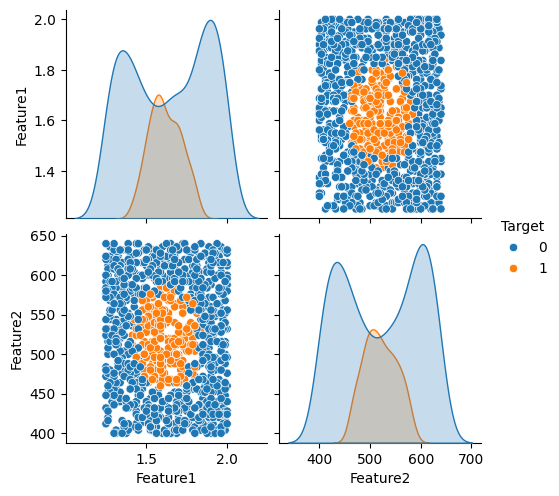

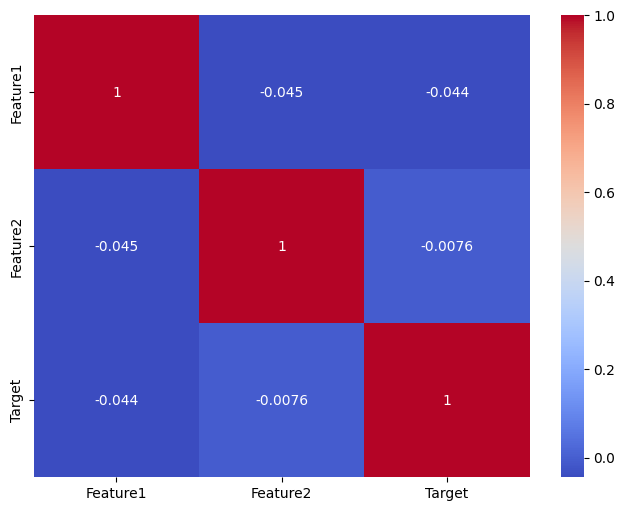

In [58]:
df_clean.dropna(subset=['Target'], inplace=True)
df_clean['Target'] = df_clean['Target'].map({'Yes': 1, 'No': 0})

print(df_clean.info())
print(df_clean.describe())


print(df_clean.isnull().sum())
sns.pairplot(df_clean, hue='Target')
plt.show()


plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.show()

In [63]:
numerical_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df_clean = df[~outlier_mask]

In [64]:
X = df_clean_processed[['Feature1', 'Feature2']]
y = df_clean_processed['Target']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [70]:
import pandas as pd

# Combine X and y to clean together
# Convert X_train to DataFrame for concatenation
data = pd.concat([pd.DataFrame(X_train), y_train], axis=1)

# Drop rows where y is NaN
data = data.dropna(subset=[y_train.name])

# Split again
X_train = data.drop(columns=[y_train.name])
y_train = data[y_train.name]

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Instead of relying on global X and y (which were corrupted),
# re-process df_clean to ensure 'Target' is numerical and no NaNs.
# df_clean (Variable #12) currently has 'Target' as 'Yes'/'No' strings.
processed_df = df_clean.copy() # Make a copy to avoid SettingWithCopyWarning

# Ensure 'Target' is numerical (0/1) and handle NaNs
processed_df.dropna(subset=['Target'], inplace=True)
processed_df['Target'] = processed_df['Target'].map({'Yes': 1, 'No': 0})

# Now create X_clean and y_clean from the processed_df
X_clean = processed_df[['Feature1', 'Feature2']]
y_clean = processed_df['Target']

print("Clean data shape:", X_clean.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

Clean data shape: (999, 2)


LogisticRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


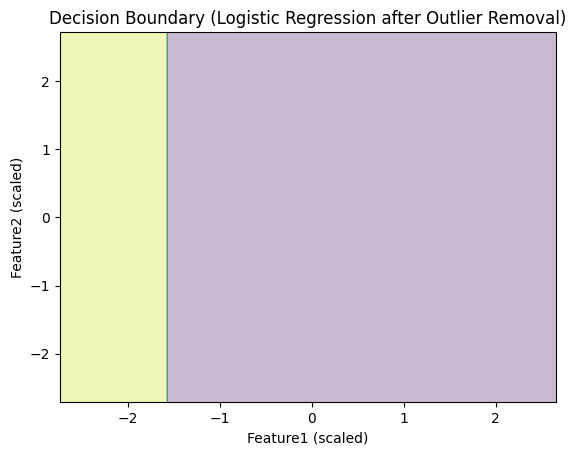

In [74]:
import numpy as np
import matplotlib.pyplot as plt

X_vis = scaler.transform(X)

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolors='k')
plt.title("Decision Boundary (Logistic Regression after Outlier Removal)")
plt.xlabel("Feature1 (scaled)")
plt.ylabel("Feature2 (scaled)")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


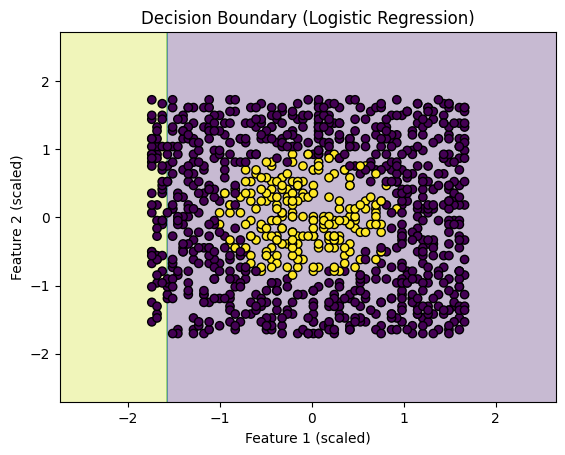

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# Use CLEANED data (IMPORTANT)
X_vis = scaler.transform(X_clean)

# Take only first 2 features (since you're plotting 2D)
X_vis = X_vis[:, :2]
y_vis = y_clean.values  # ensure array format

# Create mesh grid
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, edgecolors='k')

plt.title("Decision Boundary (Logistic Regression)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

In [76]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.79
[[158   0]
 [ 42   0]]
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       158
           1       0.00      0.00      0.00        42

    accuracy                           0.79       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.62      0.79      0.70       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
